# Chapter 5.3 — Cellular Knobs at Tissue Scale

Chapter 2 turned the ion-channel knobs — `GNa`, `GKr`, and the rest — on a single cell and watched the
action-potential *shape* change. This notebook takes those *same* knobs into *tissue* and watches what
they do to the travelling *wave*. It is the bridge of the whole series: a channel you metered on one
cell in Chapter 2 turns out to set how fast the heartbeat spreads, whether it spreads at all, and how
long a wave it makes.

We change a conductance in tissue with `sim.scale_conductance(NAME, factor)` — the tissue counterpart
of Chapter 2's `single_cell(conductances=...)`.

**What you'll learn**

1. **`GNa` (sodium) sets conduction speed** — the same current that makes the action potential's
   upstroke also drives the wave into the next cell, so lowering it **slows** the wave...
2. **...and, pushed far, blocks it** — too little sodium and the wave decays as it travels and dies
   partway across (a source–sink failure, the mechanism from notebook 5.2).
3. **`GKr` (hERG) sets the wavelength** — blocking it lengthens the action potential, which lengthens
   the **refractory period**, which lengthens the **wavelength** of the wave — without changing its
   speed.

**Runtime**: about a minute. On Colab add ~a minute the first time for the install.

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
# If it is already installed, this does nothing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core - this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/Zimmerman-Research-Group/CardiacCore.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc
import matplotlib.pyplot as plt   # only used to plot the numbers we measure

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. Sodium (`GNa`) sets the speed

In Chapter 2, `GNa` controlled the **upstroke** — the near-vertical jump at the start of the action
potential. In tissue that upstroke does double duty: the sodium current that lifts a cell also spills
into its neighbours and lifts *them* to threshold. So sodium is not just the cell's trigger, it is the
wave's engine. Weaken it and the wave should slow.

The helper builds our standard strip, optionally scales `GNa`, runs, and returns the conduction
velocity. We use a strong stimulus (`-80`) so the wave always *launches* — then the only thing changing
the velocity is the sodium knob.

In [3]:
def cv_at_GNa(factor):
    """Conduction velocity (cm/s) with sodium current scaled by `factor` (1.0 = healthy)."""
    g    = cc.Grid(101, 31, 0.01)
    cond = cc.ConductivityConfig.bidomain(1.74, 6.25)
    stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)
    sim  = cc.monodomain(g, "ttp06", cond, stim, dt=0.1)
    if factor != 1.0:
        sim.scale_conductance("GNa", factor)      # scale the sodium conductance in the tissue
    return sim.run(t_end=35.0, save_every=0.5).cv(x1=20, x2=70, y=15)

factors = [1.0, 0.5, 0.35, 0.2]
cvs = [cv_at_GNa(f) for f in factors]

for f, cv in zip(factors, cvs):
    print(f"GNa x {f:<4}:  CV = {cv:.1f} cm/s")

GNa x 1.0 :  CV = 56.7 cm/s
GNa x 0.5 :  CV = 44.7 cm/s
GNa x 0.35:  CV = 38.6 cm/s
GNa x 0.2 :  CV = 28.8 cm/s


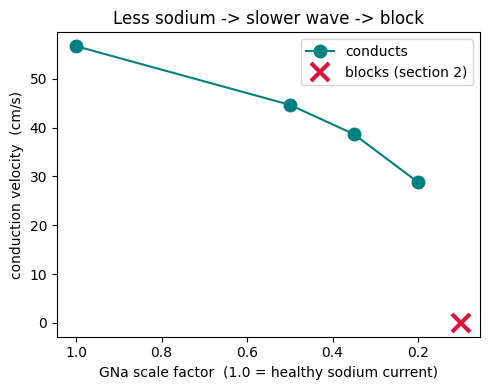

In [4]:
plt.figure(figsize=(5, 4))
plt.plot(factors, cvs, "o-", color="teal", ms=9, label="conducts")
plt.plot([0.1], [0], "x", color="crimson", ms=13, mew=3, label="blocks (section 2)")
plt.xlabel("GNa scale factor  (1.0 = healthy sodium current)")
plt.ylabel("conduction velocity  (cm/s)")
plt.title("Less sodium -> slower wave -> block")
plt.gca().invert_xaxis()          # read left-to-right as "removing sodium"
plt.legend()
plt.tight_layout()
plt.show()

Sodium and speed track together: healthy tissue runs at **~57 cm/s**, half the sodium drops it to
**~45**, and at a fifth (`0.2`) the wave crawls at **~29 cm/s** — half speed. This is exactly why sodium-
channel blockers (class I antiarrhythmics, or a fever unmasking a Brugada mutation) slow conduction, and
why that slowing shows up on an ECG as a widened QRS. The wave's engine is running lean.

---
## 2. Too little sodium blocks the wave

Keep removing sodium and slowing turns into **failure**. Below about a fifth of normal, each cell's
upstroke is too feeble to bring its neighbour all the way to threshold, so the wave loses amplitude as
it goes and eventually dies — even though it launched cleanly. Run it at a tenth of normal sodium and
draw the activation map:

ImageInfo(unsaved, 1060x412, panels=1, range=(2.1, 54.5), 24,539 bytes)
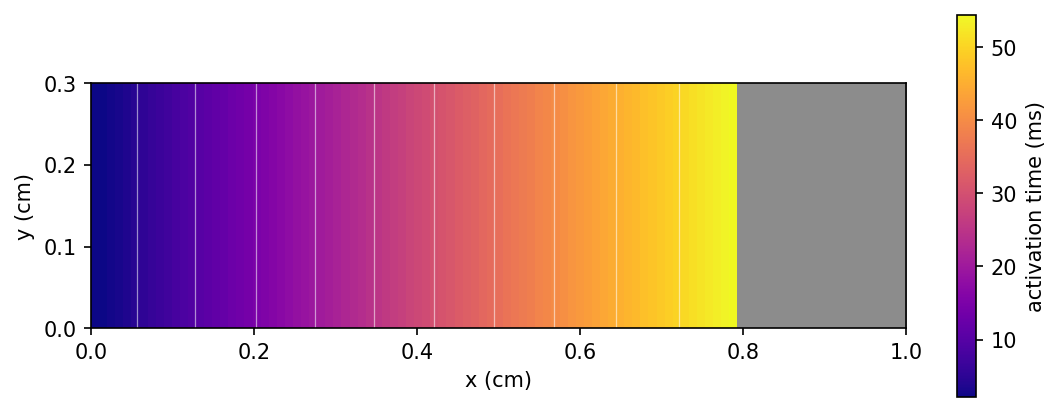

In [5]:
g    = cc.Grid(101, 31, 0.01)
cond = cc.ConductivityConfig.bidomain(1.74, 6.25)
stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)
sim  = cc.monodomain(g, "ttp06", cond, stim, dt=0.1)
sim.scale_conductance("GNa", 0.1)                 # a tenth of normal sodium
r_block = sim.run(t_end=55.0, save_every=0.5)

r_block.image(what="activation")                  # where did the wave reach?

The wave launches at the left and pushes rightward, but look at the isochrones: they **spread
farther apart** as it goes — the wave is *decelerating* — and past about **0.8 cm** the tissue stays
**dark**. The wave ran out of steam and stopped in the middle of healthy tissue. Nothing is wrong with
the cells beyond the block line; the wave simply couldn't charge them.

This is the **source–sink** failure from notebook 5.2, now driven from the cellular side. Each freshly-
excited cell is a current *source*; the resting cells ahead are its *sink*. Weaken the sodium current
and you weaken every source, until it can no longer fill the sink in front of it. `cardiac_core` lets you
measure this directly — `r.fields.source_sink` is the source-minus-sink map, and `cc.safety_factor(r)`
reduces it to one number per node (below 1 means the wave can't sustain itself there) — but the picture
already tells the story: **conduction is a balance, and sodium sets the supply side.**

---
## 3. hERG (`GKr`) sets the wavelength

`GKr` is a different kind of knob. In Chapter 2, blocking it (the hERG channel — the one so many drugs
trip over) **lengthened** the action potential, because `I_Kr` is a repolarising current and taking it
away lets the plateau run long. That does almost nothing to conduction *speed* — the upstroke is
untouched — but it changes something else the wave cares about: its **wavelength**.

The wavelength is how much tissue a single wave occupies at once: roughly `wavelength = CV x refractory
period`. A longer action potential keeps each cell busy (refractory) for longer, so the excited band
stretches out. Let's measure both pieces — the action-potential duration on one cell (as in Chapter 2)
and the conduction velocity in tissue — for healthy tissue and with hERG half-blocked.

In [6]:
def apd_and_cv(gkr_factor):
    # APD on a single cell (a cell property — cheap to measure on one cell, exactly as in Chapter 2)
    drug = None if gkr_factor == 1.0 else {"GKr": gkr_factor}
    sc = cc.single_cell("ttp06", celltype="EPI", pre_pace=1, bcl=500, dt=0.1, conductances=drug)
    apd = sc.apd(0.9)

    # CV in the tissue strip (same helper idea as section 1, but scaling GKr instead of GNa)
    g    = cc.Grid(101, 31, 0.01)
    cond = cc.ConductivityConfig.bidomain(1.74, 6.25)
    stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)
    sim  = cc.monodomain(g, "ttp06", cond, stim, dt=0.1)
    if gkr_factor != 1.0:
        sim.scale_conductance("GKr", gkr_factor)
    cv = sim.run(t_end=35.0, save_every=0.5).cv(20, 70, 15)
    return apd, cv

for f in [1.0, 0.5]:
    apd, cv = apd_and_cv(f)
    wl = cc.wavelength(cv, apd, kind="apd")        # CV x refractory / 1000  (cm); APD used as the proxy
    label = "healthy" if f == 1.0 else "hERG 50% block"
    print(f"{label:<15}:  APD90 = {apd:.0f} ms   CV = {cv:.1f} cm/s   wavelength = {wl:.1f} cm")

/tmp/ipykernel_442339/1386668900.py:19: UserWarning: wavelength(kind='apd') uses APD90 as an ERP proxy; it underestimates the wavelength when ERP > APD90 (post-repolarization refractoriness). Use kind='erp' with a measured ERP (protocols.erp) when refractoriness matters.
  wl = cc.wavelength(cv, apd, kind="apd")        # CV x refractory / 1000  (cm); APD used as the proxy


healthy        :  APD90 = 217 ms   CV = 56.7 cm/s   wavelength = 12.3 cm


hERG 50% block :  APD90 = 239 ms   CV = 56.7 cm/s   wavelength = 13.5 cm


Half-blocking hERG stretches the action potential from **217 to 239 ms**, leaves conduction velocity
**unchanged** at ~57 cm/s, and so lengthens the wavelength from about **12.3 to 13.5 cm**. (You'll see a
note that we used APD90 as a stand-in for the true refractory period — it slightly *under*-estimates the
real wavelength, but the *direction* is exactly right.)

Why care about a longer wavelength? Because the wavelength is the length of circuit a re-entrant wave
needs to chase its own tail. A **longer** wavelength makes re-entry *harder* to sustain (there isn't
room) — the protective side of prolonging the action potential. The flip side is the danger Chapter 2
hinted at: an over-long, unstable action potential can trigger the extra beats that *start* an
arrhythmia. Same knob, both faces. Notebook 4 (pacing) and its reentry example are where wavelength
earns its keep.

### Try it yourself

1. **Find the sodium block threshold.** In section 1, add smaller factors to the list — try
   `[0.5, 0.3, 0.2, 0.15, 0.12]`. Watch the velocity fall, and note where `r.cv(...)` starts returning
   `nan` (the wave no longer reaches the far electrode). That crossover is where slowing becomes block.
2. **Push hERG harder.** In section 3, change the factor list to `[1.0, 0.5, 0.25]`. The action
   potential — and the wavelength — grow further. (A quarter of normal hERG is a heavy dose of a
   QT-prolonging drug.)

---
## Recap

- **`GNa` (sodium) is the wave's engine**: the upstroke current that excites each cell also drives the
  next, so lowering `GNa` **slows** conduction (class-I drugs, Brugada, a widened QRS).
- **Pushed far, low sodium blocks the wave** — it decrements as it travels and dies in healthy tissue,
  a source–sink failure driven from the cellular side.
- **`GKr` (hERG) sets the wavelength, not the speed**: blocking it lengthens the action potential →
  longer refractory period → longer **wavelength**, with CV untouched — the double-edged story behind
  QT-prolonging drugs.

**Where next**: notebook 5.4 is the discipline that makes all of these numbers trustworthy — the grid
spacing and time step you ran them at. Too coarse a grid and a healthy wave can *look* slow or even
blocked, purely as a numerical artifact. Before you believe any tuned number, you check it there.